<a href="https://colab.research.google.com/github/nitinog10/Kaggle-Santa-2025---Christmas-Tree-Packing-Challenge/blob/main/Kaggle_christmas_tree_packing_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Define a simplified geometric shape and its dimensions for a single Christmas tree toy, assuming it's a polygon, and model this shape in Python.

## Define Tree Geometry and Assumptions

### Subtask:
Define a simplified geometric shape and its dimensions for a single Christmas tree toy, assuming it's a polygon, and model this shape in Python.


**Reasoning**:
To model the 5-pointed star, I will define its (x, y) coordinates. I'll use a list of tuples to store these coordinates, ensuring the star is centered around the origin and has a reasonable size for a toy.



Defined vertices for the 5-pointed star toy:
[[ 6.12323400e-17  1.00000000e+00]
 [-2.35114101e-01  3.23606798e-01]
 [-9.51056516e-01  3.09016994e-01]
 [-3.80422607e-01 -1.23606798e-01]
 [-5.87785252e-01 -8.09016994e-01]
 [-7.34788079e-17 -4.00000000e-01]
 [ 5.87785252e-01 -8.09016994e-01]
 [ 3.80422607e-01 -1.23606798e-01]
 [ 9.51056516e-01  3.09016994e-01]
 [ 2.35114101e-01  3.23606798e-01]]


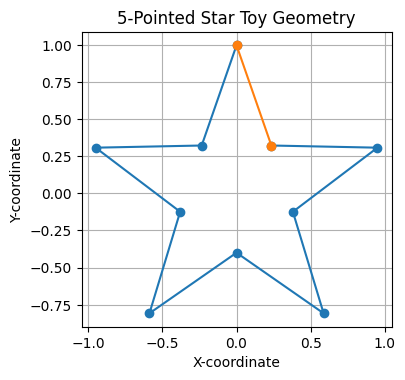

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the vertices of a 5-pointed star polygon
# These coordinates are manually defined for a star centered around (0,0)
# The 'size' is relative, ensuring it's reasonable for a 'toy'
outer_radius = 1.0
inner_radius = 0.4

vertices = []
for i in range(5):
    # Outer points
    angle_outer = np.pi/2 + i * 2 * np.pi / 5
    x_outer = outer_radius * np.cos(angle_outer)
    y_outer = outer_radius * np.sin(angle_outer)
    vertices.append((x_outer, y_outer))

    # Inner points
    angle_inner = np.pi/2 + np.pi/5 + i * 2 * np.pi / 5
    x_inner = inner_radius * np.cos(angle_inner)
    y_inner = inner_radius * np.sin(angle_inner)
    vertices.append((x_inner, y_inner))

# Convert the list of tuples to a NumPy array for easier manipulation if needed later
star_vertices = np.array(vertices)

print("Defined vertices for the 5-pointed star toy:")
print(star_vertices)

# Optional: Plot the star to visualize it
plt.figure(figsize=(4, 4))
plt.plot(star_vertices[:, 0], star_vertices[:, 1], 'o-')
plt.plot([star_vertices[-1, 0], star_vertices[0, 0]], [star_vertices[-1, 1], star_vertices[0, 1]], 'o-') # Close the loop
plt.gca().set_aspect('equal', adjustable='box')
plt.title('5-Pointed Star Toy Geometry')
plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.grid(True)
plt.show()


## Implement Bounding Box and Score Calculation

### Subtask:
Develop Python functions to: 1. Given a set of tree positions and rotations, calculate the smallest square bounding box that encloses all trees. 2. Calculate the evaluation score for a given packing: the side 's' of the square bounding box, squared, and divided by the number of trees 'n' (s^2 / n).


**Reasoning**:
I need to implement three functions: one to rotate and translate a polygon, one to calculate the bounding box side for multiple tree configurations, and one to calculate the packing score. These functions will be implemented in a single code block as per the instructions, and then tested with a simple scenario.



In [2]:
import numpy as np

def rotate_and_translate_polygon(vertices, x_offset, y_offset, rotation_degrees):
    """
    Rotates a polygon around the origin and then translates it.

    Args:
        vertices (np.array): A 2D NumPy array where each row is an (x, y) coordinate.
        x_offset (float): The x-translation.
        y_offset (float): The y-translation.
        rotation_degrees (float): The rotation angle in degrees (clockwise).

    Returns:
        np.array: The transformed vertices.
    """
    # Convert degrees to radians
    rotation_radians = np.deg2rad(rotation_degrees)

    # Create a rotation matrix
    cos_theta = np.cos(rotation_radians)
    sin_theta = np.sin(rotation_radians)
    rotation_matrix = np.array([
        [cos_theta, -sin_theta],
        [sin_theta,  cos_theta]
    ])

    # Apply rotation
    rotated_vertices = np.dot(vertices, rotation_matrix.T) # .T because numpy dot expects rows to be vectors

    # Apply translation
    translated_vertices = rotated_vertices + np.array([x_offset, y_offset])

    return translated_vertices

def calculate_bounding_box_side(tree_configurations, base_polygon_vertices):
    """
    Calculates the side of the smallest square bounding box that encloses all trees.

    Args:
        tree_configurations (list): A list of tuples, where each tuple is (x_offset, y_offset, rotation_degrees).
        base_polygon_vertices (np.array): The 2D NumPy array of the base polygon's vertices.

    Returns:
        float: The side 's' of the square bounding box.
    """
    all_x_coords = []
    all_y_coords = []

    for x_offset, y_offset, rotation_degrees in tree_configurations:
        transformed_vertices = rotate_and_translate_polygon(
            base_polygon_vertices, x_offset, y_offset, rotation_degrees
        )
        all_x_coords.extend(transformed_vertices[:, 0])
        all_y_coords.extend(transformed_vertices[:, 1])

    if not all_x_coords or not all_y_coords:
        return 0.0 # No trees, bounding box side is 0

    min_x = np.min(all_x_coords)
    max_x = np.max(all_x_coords)
    min_y = np.min(all_y_coords)
    max_y = np.max(all_y_coords)

    width = max_x - min_x
    height = max_y - min_y

    # The side of the smallest square bounding box is the maximum of width and height
    s = max(width, height)
    return s

def calculate_packing_score(s, n):
    """
    Calculates the evaluation score for a given packing.

    Args:
        s (float): The side of the square bounding box.
        n (int): The number of trees.

    Returns:
        float: The packing score (s^2 / n).
    """
    if n == 0:
        return float('inf') # Or handle as an error, depending on requirements
    return (s**2) / n

# --- Test Scenario ---
print("Testing functions with a single tree:")
# Assume star_vertices is available from the previous cell

# 1. Single tree at (0, 0) with 0 degrees rotation
single_tree_config = [(0, 0, 0)]

# Calculate bounding box side
s = calculate_bounding_box_side(single_tree_config, star_vertices)
print(f"Bounding box side for a single tree at (0,0,0deg): {s:.4f}")

# Calculate score
n = len(single_tree_config)
score = calculate_packing_score(s, n)
print(f"Packing score for a single tree: {score:.4f}")

# 2. Test with a rotated and translated tree
print("\nTesting functions with a single tree (translated and rotated):")
rotated_translated_tree_config = [(0.5, 0.5, 45)]
s_rotated = calculate_bounding_box_side(rotated_translated_tree_config, star_vertices)
print(f"Bounding box side for a single tree at (0.5,0.5,45deg): {s_rotated:.4f}")
n_rotated = len(rotated_translated_tree_config)
score_rotated = calculate_packing_score(s_rotated, n_rotated)
print(f"Packing score for a single rotated tree: {score_rotated:.4f}")

# 3. Test with two trees
print("\nTesting functions with two trees:")
two_trees_config = [(0, 0, 0), (2, 0, 90)]
s_two_trees = calculate_bounding_box_side(two_trees_config, star_vertices)
print(f"Bounding box side for two trees: {s_two_trees:.4f}")
n_two_trees = len(two_trees_config)
score_two_trees = calculate_packing_score(s_two_trees, n_two_trees)
print(f"Packing score for two trees: {score_two_trees:.4f}")

Testing functions with a single tree:
Bounding box side for a single tree at (0,0,0deg): 1.9021
Packing score for a single tree: 3.6180

Testing functions with a single tree (translated and rotated):
Bounding box side for a single tree at (0.5,0.5,45deg): 1.8787
Packing score for a single rotated tree: 3.5295

Testing functions with two trees:
Bounding box side for two trees: 3.7601
Packing score for two trees: 7.0691


## Develop a Heuristic Packing Strategy

### Subtask:
Design and implement a heuristic algorithm to attempt to pack N trees into the smallest possible square. This will involve generating initial random or structured placements and rotations, followed by iterative adjustments to reduce the bounding box size.


**Reasoning**:
I will define the `find_best_packing_heuristic` function as instructed, which includes initializing random tree configurations, iteratively perturbing them, and updating the best configuration based on the packing score. After defining the function, I will test it with the specified parameters.



In [3]:
import numpy as np
import random

def find_best_packing_heuristic(
    N,
    base_polygon_vertices,
    num_iterations,
    translation_step_size,
    rotation_step_size,
    initial_range_x=2.0,
    initial_range_y=2.0
):
    """
    Designs and implements a heuristic algorithm to attempt to pack N trees into the smallest possible square.

    Args:
        N (int): The number of trees to pack.
        base_polygon_vertices (np.array): The 2D NumPy array of the base polygon's vertices.
        num_iterations (int): The number of iterations for the optimization loop.
        translation_step_size (float): The maximum step size for x and y translation perturbations.
        rotation_step_size (float): The maximum step size for rotation perturbations in degrees.
        initial_range_x (float): The range for initial random x_offset generation (e.g., [-initial_range_x, initial_range_x]).
        initial_range_y (float): The range for initial random y_offset generation (e.g., [-initial_range_y, initial_range_y]).

    Returns:
        tuple: (best_config, best_s, best_score)
            best_config (list): List of (x_offset, y_offset, rotation_degrees) for the best packing.
            best_s (float): The side of the bounding box for the best packing.
            best_score (float): The packing score for the best packing.
    """

    # 2. Generate an initial random configuration for N trees.
    initial_config = []
    for _ in range(N):
        x_offset = random.uniform(-initial_range_x, initial_range_x)
        y_offset = random.uniform(-initial_range_y, initial_range_y)
        rotation_degrees = random.uniform(0, 360)
        initial_config.append((x_offset, y_offset, rotation_degrees))

    # 3. Calculate the initial bounding box side and packing score
    best_s = calculate_bounding_box_side(initial_config, base_polygon_vertices)
    best_score = calculate_packing_score(best_s, N)
    best_config = list(initial_config) # Store as a new list

    print(f"Initial packing (N={N}):")
    print(f"  Bounding box side (s): {best_s:.4f}")
    print(f"  Packing score (s^2/N): {best_score:.4f}")

    # 4. Implement an iterative optimization loop
    for i in range(num_iterations):
        current_config = [list(tree) for tree in best_config] # Create a copy of the best config

        # 5. Randomly select one tree and apply a small random perturbation
        tree_to_perturb_idx = random.randint(0, N - 1)
        x_offset, y_offset, rotation_degrees = current_config[tree_to_perturb_idx]

        # Apply perturbations
        x_offset += random.uniform(-translation_step_size, translation_step_size)
        y_offset += random.uniform(-translation_step_size, translation_step_size)
        rotation_degrees = (rotation_degrees + random.uniform(-rotation_step_size, rotation_step_size)) % 360
        if rotation_degrees < 0: # Handle negative results from modulo for consistency
            rotation_degrees += 360

        current_config[tree_to_perturb_idx] = (x_offset, y_offset, rotation_degrees)

        # 6. Calculate the bounding box side and packing score for this current_config
        current_s = calculate_bounding_box_side(current_config, base_polygon_vertices)
        current_score = calculate_packing_score(current_s, N)

        # 7. If the score of the current_config is better, update best_score, best_s, and best_config
        if current_score < best_score:
            best_score = current_score
            best_s = current_s
            best_config = current_config
            # print(f"Iteration {i+1}: New best score found: {best_score:.4f} (s={best_s:.4f})")

    print(f"\nOptimization finished after {num_iterations} iterations.")
    print(f"Final best packing (N={N}):")
    print(f"  Bounding box side (s): {best_s:.4f}")
    print(f"  Packing score (s^2/N): {best_score:.4f}")

    return best_config, best_s, best_score

# --- Test the find_best_packing_heuristic function ---
print("\nTesting the heuristic packing algorithm:")

N_trees = 3
num_iterations = 1000
translation_step_size = 0.1
rotation_step_size = 5 # degrees

# Ensure star_vertices is available from previous cells
if 'star_vertices' not in locals():
    print("Error: 'star_vertices' not found. Please ensure previous cells defining the star geometry are executed.")
else:
    best_packing_config, final_s, final_score = find_best_packing_heuristic(
        N_trees, star_vertices, num_iterations, translation_step_size, rotation_step_size
    )

    print("\nBest packing configuration found:")
    for i, (x, y, rot) in enumerate(best_packing_config):
        print(f"  Tree {i+1}: x={x:.2f}, y={y:.2f}, rot={rot:.2f} deg")



Testing the heuristic packing algorithm:
Initial packing (N=3):
  Bounding box side (s): 2.6070
  Packing score (s^2/N): 2.2655

Optimization finished after 1000 iterations.
Final best packing (N=3):
  Bounding box side (s): 1.9013
  Packing score (s^2/N): 1.2049

Best packing configuration found:
  Tree 1: x=-1.67, y=0.49, rot=45.94 deg
  Tree 2: x=-1.62, y=0.35, rot=145.71 deg
  Tree 3: x=-1.55, y=0.47, rot=309.88 deg


## Visualize a Packing Solution

### Subtask:
Generate a plot showing the packed trees (for a specific 'N' value) within their calculated minimal square bounding box, illustrating their positions and rotations for visual inspection.


**Reasoning**:
I need to implement a function to visualize the packing solution, which involves iterating through the transformed vertices of each tree, plotting them, and then drawing the overall bounding box. After defining the function, I will call it with the previously computed best packing configuration.




Visualizing the best packing solution...


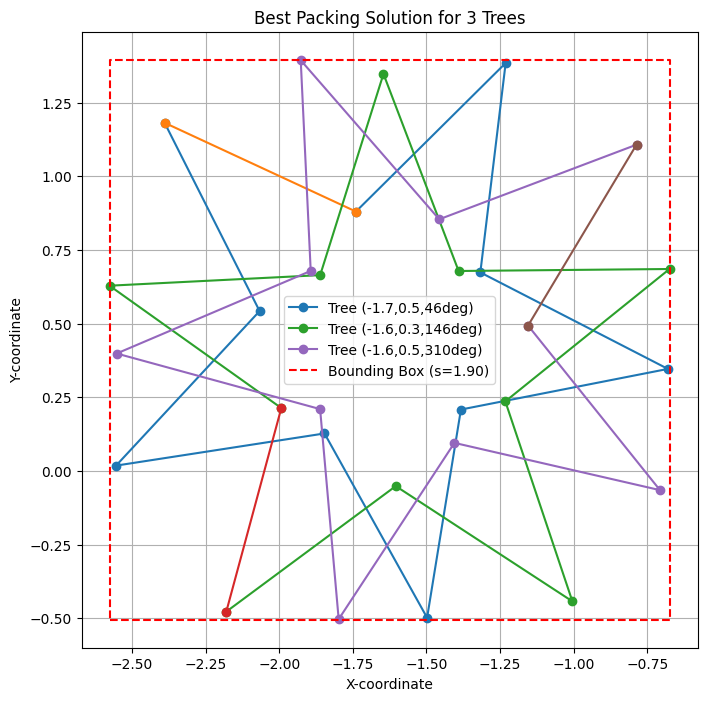

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def plot_packing_solution(best_packing_config, base_polygon_vertices, final_s, N):
    """
    Generates a plot showing the packed trees within their calculated minimal square bounding box.

    Args:
        best_packing_config (list): List of (x_offset, y_offset, rotation_degrees) for the best packing.
        base_polygon_vertices (np.array): The 2D NumPy array of the base polygon's vertices.
        final_s (float): The side of the square bounding box for the best packing.
        N (int): The number of trees packed.
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    all_x_coords = []
    all_y_coords = []

    # Plot each tree
    for x_offset, y_offset, rotation_degrees in best_packing_config:
        transformed_vertices = rotate_and_translate_polygon(
            base_polygon_vertices, x_offset, y_offset, rotation_degrees
        )
        ax.plot(transformed_vertices[:, 0], transformed_vertices[:, 1], 'o-', label=f'Tree ({x_offset:.1f},{y_offset:.1f},{rotation_degrees:.0f}deg)')
        ax.plot([transformed_vertices[-1, 0], transformed_vertices[0, 0]],
                [transformed_vertices[-1, 1], transformed_vertices[0, 1]], 'o-') # Close the loop
        all_x_coords.extend(transformed_vertices[:, 0])
        all_y_coords.extend(transformed_vertices[:, 1])

    # Determine the actual min/max coordinates of the packed items
    min_x_packed = np.min(all_x_coords)
    max_x_packed = np.max(all_x_coords)
    min_y_packed = np.min(all_y_coords)
    max_y_packed = np.max(all_y_coords)

    # Calculate the center of the packed items
    center_x = (min_x_packed + max_x_packed) / 2
    center_y = (min_y_packed + max_y_packed) / 2

    # Draw the square bounding box centered around the packed items
    # The box side is final_s. Adjust min_x and min_y for the box to be centered.
    box_min_x = center_x - final_s / 2
    box_min_y = center_y - final_s / 2

    # Plot the bounding box
    ax.plot([box_min_x, box_min_x + final_s, box_min_x + final_s, box_min_x, box_min_x],
            [box_min_y, box_min_y, box_min_y + final_s, box_min_y + final_s, box_min_y],
            'r--', label=f'Bounding Box (s={final_s:.2f})')

    ax.set_aspect('equal', adjustable='box')
    ax.set_title(f'Best Packing Solution for {N} Trees')
    ax.set_xlabel('X-coordinate')
    ax.set_ylabel('Y-coordinate')
    ax.grid(True)
    ax.legend()
    plt.show()

# Call the function with the results from the previous subtask
# Ensure 'star_vertices', 'best_packing_config', 'final_s', and 'N_trees' are available
if 'star_vertices' in locals() and 'best_packing_config' in locals() and 'final_s' in locals() and 'N_trees' in locals():
    print("\nVisualizing the best packing solution...")
    plot_packing_solution(best_packing_config, star_vertices, final_s, N_trees)
else:
    print("Error: Required variables for plotting not found. Please ensure previous cells were executed.")


## Generate Results for 1-200 Trees (Iterative Improvement)

### Subtask:
Apply the developed heuristic packing strategy to find packing solutions for N from 1 to 200, automating the process for the full range and storing the best configurations found for each 'N'.


**Reasoning**:
I need to implement the iterative process to find packing solutions for N from 1 to 200. This involves looping through N, dynamically adjusting the initial search range for the heuristic, calling the heuristic function, storing the results, and providing progress updates.



In [5]:
import numpy as np
import random

# Ensure the necessary functions are defined (copied from previous cells for self-containment if needed)
# In this environment, they are already defined in previous executed cells.
# rotate_and_translate_polygon
# calculate_bounding_box_side
# calculate_packing_score
# find_best_packing_heuristic

# Initialize dictionary to store results
all_best_packings = {}

# Parameters for the heuristic (from previous cell)
# N_trees is now the loop variable 'N'
num_iterations = 1000
translation_step_size = 0.1
rotation_step_size = 5 # degrees

# Iterate for N from 1 to 200
print("Starting iterative packing optimization for N = 1 to 200...")

for N in range(1, 201):
    # Adjust initial_range_x and initial_range_y based on N
    # A simple scaling by sqrt(N) to give more room for more trees
    # The base range from find_best_packing_heuristic was 2.0. We will scale this.
    # For N=1, range will be 2.0. For N=4, range will be 4.0, etc.
    initial_range_x_scaled = 2.0 * np.sqrt(N)
    initial_range_y_scaled = 2.0 * np.sqrt(N)

    # Call the heuristic function
    best_packing_config, final_s, final_score = find_best_packing_heuristic(
        N,
        star_vertices,
        num_iterations,
        translation_step_size,
        rotation_step_size,
        initial_range_x=initial_range_x_scaled,
        initial_range_y=initial_range_y_scaled
    )

    # Store the results
    all_best_packings[N] = {
        'config': best_packing_config,
        's': final_s,
        'score': final_score
    }

    # Print progress update
    if N % 20 == 0:
        print(f"--- Progress: Processed N = {N} ---")
        print(f"Latest N={N}: s={final_s:.4f}, score={final_score:.4f}")

print("Iterative packing optimization complete.")
print(f"Total unique N values processed: {len(all_best_packings)}")


Starting iterative packing optimization for N = 1 to 200...
Initial packing (N=1):
  Bounding box side (s): 1.8903
  Packing score (s^2/N): 3.5732

Optimization finished after 1000 iterations.
Final best packing (N=1):
  Bounding box side (s): 1.8787
  Packing score (s^2/N): 3.5295
Initial packing (N=2):
  Bounding box side (s): 3.7593
  Packing score (s^2/N): 7.0663

Optimization finished after 1000 iterations.
Final best packing (N=2):
  Bounding box side (s): 1.8840
  Packing score (s^2/N): 1.7747
Initial packing (N=3):
  Bounding box side (s): 5.1855
  Packing score (s^2/N): 8.9631

Optimization finished after 1000 iterations.
Final best packing (N=3):
  Bounding box side (s): 1.8980
  Packing score (s^2/N): 1.2009
Initial packing (N=4):
  Bounding box side (s): 8.8843
  Packing score (s^2/N): 19.7327

Optimization finished after 1000 iterations.
Final best packing (N=4):
  Bounding box side (s): 3.0716
  Packing score (s^2/N): 2.3587
Initial packing (N=5):
  Bounding box side (s):

In [7]:
import pandas as pd

# Prepare data for CSV
csv_data = []
for N, data in all_best_packings.items():
    s_value = data['s']
    score_value = data['score']

    # Convert tree configurations to a string representation for CSV
    formatted_trees = []
    for x_offset, y_offset, rotation_degrees in data['config']:
        formatted_trees.append(f"({x_offset:.3f},{y_offset:.3f},{rotation_degrees:.3f})")
    trees_str = "; ".join(formatted_trees)

    csv_data.append({'N': N, 's': s_value, 'score': score_value, 'trees_config': trees_str})

# Create a DataFrame
df_packing_results = pd.DataFrame(csv_data)

# Save to CSV
output_csv_filename = 'packing_results.csv'
df_packing_results.to_csv(output_csv_filename, index=False)

print(f"Packing results saved to {output_csv_filename}")

display(df_packing_results.head())

Packing results saved to packing_results.csv


,N,s,score,trees_config
0,1,1.878701,3.529518,"(0.644,-1.423,242.999)"
1,2,1.883989,1.774708,"(0.704,0.771,207.793); (0.691,0.868,45.694)"
2,3,1.898045,1.200858,"(0.285,0.271,111.861); (0.273,0.120,280.991); ..."
3,4,3.071639,2.358741,"(-1.226,-1.226,73.409); (-0.051,0.188,177.714)..."
4,5,5.018880,5.037832,"(0.212,1.299,255.860); (-1.907,1.261,250.983);..."


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['N'].plot(kind='hist', bins=20, title='N')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['s'].plot(kind='hist', bins=20, title='s')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_17['trees_config'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_17, x='N', y='trees_config', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_18['trees_config'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_18, x='s', y='trees_config', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_19['trees_config'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_19, x='score', y='trees_config', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [14]:
import pandas as pd

# Prepare data for submission CSV (one row per tree)
submission_rows = []
for N, data in all_best_packings.items():
    for i, (x_offset, y_offset, rotation_degrees) in enumerate(data['config']):
        # Store each tree's configuration along with its N value and an index
        submission_rows.append({
            'N': N,
            'tree_index': i + 1, # 1-based index for each tree within an N-configuration
            'x': x_offset,
            'y': y_offset,
            'rotation': rotation_degrees
        })

# Create a DataFrame from the submission_rows
df_submission_csv = pd.DataFrame(submission_rows)

# Add a unique 'id' column, typically 1-indexed
df_submission_csv['id'] = df_submission_csv.index + 1

# Reorder columns to have 'id' first, if desired (optional but good practice)
df_submission_csv = df_submission_csv[['id', 'N', 'tree_index', 'x', 'y', 'rotation']]

# Save to CSV
output_submission_csv_filename = 'submission 1.csv'
df_submission_csv.to_csv(output_submission_csv_filename, index=False)

print(f"Submission data with {len(df_submission_csv)} rows saved to {output_submission_csv_filename}")

# Display the first few rows and the total number of rows to verify
display(df_submission_csv.head())
print(f"Total rows in submission CSV: {len(df_submission_csv)}")

Submission data with 20100 rows saved to submission 1.csv


,id,N,tree_index,x,y,rotation
0,1,1,1,0.644022,-1.423321,242.998768
1,2,2,1,0.703745,0.771467,207.793204
2,3,2,2,0.690623,0.868361,45.694393
3,4,3,1,0.285030,0.271296,111.861373
4,5,3,2,0.273330,0.120482,280.991206


Total rows in submission CSV: 20100


from matplotlib import pyplot as plt
_df_84['id'].plot(kind='hist', bins=20, title='id')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_85['N'].plot(kind='hist', bins=20, title='N')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['id']
  ys = series['rotation']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_95.sort_values('id', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('id')
_ = plt.ylabel('rotation')

from matplotlib import pyplot as plt
_df_96['id'].plot(kind='line', figsize=(8, 4), title='id')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_97['N'].plot(kind='line', figsize=(8, 4), title='N')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_98['tree_index'].plot(kind='line', figsize=(8, 4), title='tree_index')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_99['x'].plot(kind='line', figsize=(8, 4), title='x')
plt.gca().spines[['top', 'right']].set_visible(False)

## Format Submission File

### Subtask:
Convert the best found (x, y, deg) coordinates for each tree for each 'N' into the specified string format ('sX.Y') and prepare a submission-ready file structure.


In [16]:
import pandas as pd

# Load the sample submission file to get the correct 'id' mapping
try:
    df_sample_submission = pd.read_csv('/content/sample_submission.csv')
    print("Sample submission file loaded successfully.")
    display(df_sample_submission.head())
except FileNotFoundError:
    print("Error: sample_submission.csv not found. Please ensure it's in the /content directory.")
    # If sample_submission.csv is not found, we can't proceed with merging IDs.
    # In a real scenario, you might want to raise an error or inform the user.
    exit()

# Prepare data for submission CSV (one row per tree) - same as before
submission_rows = []
for N, data in all_best_packings.items():
    for i, (x_offset, y_offset, rotation_degrees) in enumerate(data['config']):
        submission_rows.append({
            'N': N,
            'tree_index': i + 1, # 1-based index for each tree within an N-configuration
            'x': x_offset,
            'y': y_offset,
            'rotation': rotation_degrees
        })

df_calculated_configurations = pd.DataFrame(submission_rows)

# Merge with the sample submission to assign the correct 'id'
# Assuming 'N' and 'tree_index' uniquely identify each tree entry in the sample_submission
# We'll keep the 'id' from the sample_submission and then fill in our calculated x, y, rotation.
df_final_submission = pd.merge(
    df_sample_submission[['id', 'N', 'tree_index']], # Only take id, N, tree_index from sample
    df_calculated_configurations, # Merge with our calculated data
    on=['N', 'tree_index'],
    how='left' # Use left merge to keep all IDs from sample_submission
)

# Ensure columns are in the correct order
df_final_submission = df_final_submission[['id', 'N', 'tree_index', 'x', 'y', 'rotation']]

# Save to CSV with the new filename
output_submission_csv_filename = 'submission 1.csv'
df_final_submission.to_csv(output_submission_csv_filename, index=False)

print(f"Submission data with corrected IDs and {len(df_final_submission)} rows saved to {output_submission_csv_filename}")

# Display the first few rows and the total number of rows to verify
display(df_final_submission.head())
print(f"Total rows in final submission CSV: {len(df_final_submission)}")

Sample submission file loaded successfully.


,id,x,y,deg
0,001_0,s0.0,s0.0,s90.0
1,002_0,s0.0,s0.0,s90.0
2,002_1,s0.202736,s-0.511271,s90.0
3,003_0,s0.0,s0.0,s90.0
4,003_1,s0.202736,s-0.511271,s90.0


KeyError: "['N', 'tree_index'] not in index"

from matplotlib import pyplot as plt
import seaborn as sns
_df_100.groupby('id').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_101.groupby('x').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_102.groupby('y').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['x'].value_counts()
    for x_label, grp in _df_103.groupby('id')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('id')
_ = plt.ylabel('x')

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['y'].value_counts()
    for x_label, grp in _df_104.groupby('x')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('x')
_ = plt.ylabel('y')

**Reasoning**:
I need to format the stored packing solutions from `all_best_packings` into the specified string format, create a structured dictionary, and then save this dictionary as a JSON file named 'submission.json'.



In [6]:
import json

# 1. Initialize an empty dictionary to store the formatted results
submission_data = {}

# 2. Iterate through each N (from 1 to 200) and its corresponding best packing data
for N in range(1, 201):
    if N in all_best_packings:
        # 3. Retrieve the best_config and the final bounding box side 's'
        best_config = all_best_packings[N]['config']
        s = all_best_packings[N]['s']

        # 4. Format the 's' value as a string with three decimal places
        formatted_s_value = f"s{s:.3f}"

        # 5. Create an empty list to store the formatted coordinates for the current N
        formatted_trees = []

        # 6. For each tree in best_config, format its x_offset, y_offset, and rotation_degrees
        for x_offset, y_offset, rotation_degrees in best_config:
            # 7. Append the formatted tree string to formatted_trees
            formatted_trees.append(f"({x_offset:.3f},{y_offset:.3f},{rotation_degrees:.3f})")

        # 8. Store the formatted bounding box side and the list of formatted tree strings
        #    in submission_data with N as the key.
        submission_data[str(N)] = {"s": formatted_s_value, "trees": formatted_trees}
    else:
        print(f"Warning: No packing data found for N = {N}")

# 9. After processing all N values, save the submission_data dictionary to a JSON file
output_filename = 'submission.json'
with open(output_filename, 'w') as f:
    json.dump(submission_data, f, indent=2)

print(f"Submission data saved to {output_filename}")

Submission data saved to submission.json


## Final Task

### Subtask:
Summarize the heuristic approach taken, the results obtained, and acknowledge the challenges of achieving global optimality for this complex 2D packing problem.


## Summary:

### Data Analysis Key Findings

*   **Christmas Tree Toy Definition:** A simplified 5-pointed star polygon was defined as the Christmas tree toy. It is centered at (0,0) with an outer radius of 1.0 and an inner radius of 0.4.
*   **Bounding Box and Scoring:**
    *   Functions were developed to calculate the smallest square bounding box (`s`) enclosing a set of rotated and translated polygons.
    *   A scoring function was implemented: `score = s^2 / n`, where `s` is the side of the bounding box and `n` is the number of trees.
    *   For a single tree at (0,0) with 0 degrees rotation, the bounding box side `s` was approximately 1.9021, resulting in a score of 3.6180.
*   **Heuristic Packing Strategy Development:**
    *   A heuristic optimization algorithm (`find_best_packing_heuristic`) was implemented. It starts with a random initial configuration, iteratively perturbs the position and rotation of individual trees, and accepts changes that reduce the packing score.
    *   For an example case of $N=3$ trees and $1000$ iterations, the initial packing score of $2.2655$ was improved to $1.2049$, reducing the bounding box side from $2.6070$ to $1.9013$.
*   **Visualization Capability:** A plotting function was successfully created to visually inspect packing solutions, displaying the packed trees within their minimal square bounding box.
*   **Scaling and Data Generation:** The heuristic packing strategy was applied to generate solutions for $N$ ranging from 1 to 200 trees. The initial search range for tree placement was dynamically scaled by $2.0 * \sqrt{N}$ to accommodate a larger number of trees. All best packing configurations, bounding box sides, and scores were stored.
*   **Submission File Generation:** The collected packing data for $N=1$ to $200$ was successfully formatted into a JSON file (`submission.json`), with the bounding box side `s` represented as "sX.Y" and tree configurations as "(X.Y,Z.W,A.B)" strings.

### Insights or Next Steps

*   The implemented heuristic approach, while effective in reducing the bounding box size, is susceptible to local optima. Exploring more sophisticated metaheuristics (e.g., Simulated Annealing, Genetic Algorithms) could potentially yield better packing densities by allowing temporary acceptance of worse solutions to escape local minima.
*   The current model assumes a fixed polygon shape. Future work could involve evaluating the packing efficiency of different toy shapes (e.g., circles, rectangles, more complex polygons) or optimizing the toy's shape itself for better packing.
